In [1]:
import numpy as np
import emcee
from scipy import stats
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

from scipy import integrate
from scipy.stats import norm
from scipy.stats import cauchy
from astroML.plotting import hist

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
C:\Users\havef\OneDrive\Documents\conda\lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


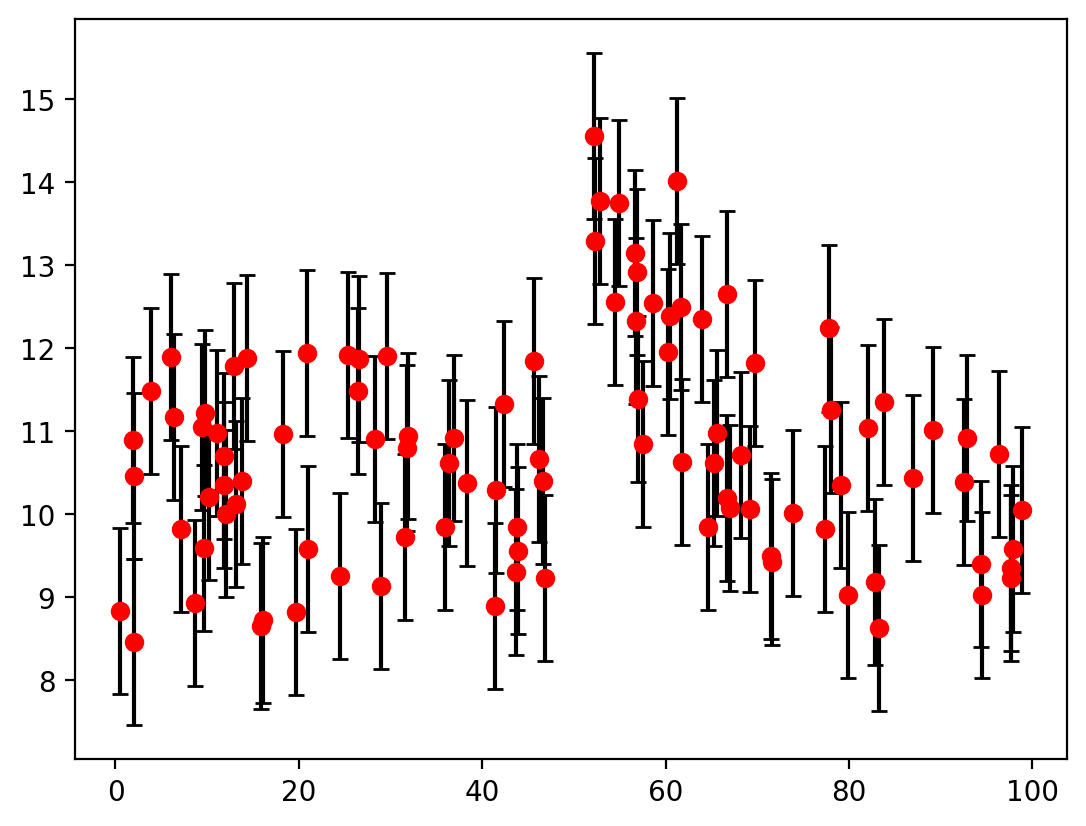

In [2]:
#importo i dati
data = np.load('transient.npy')


time = data[: , 0]
flux = data [: , 1]
sigma = data[: , 2]

#plotto i dati iniziali
plt.errorbar(data[: , 0], data[: , 1], data[: , 2] ,fmt='ro', ecolor='black', capsize=3)
plt.show()

In [3]:
def f_scalar(b , t_0 , A , alpha, t):
    if (t < t_0):
        return b
    else:
        return b + A*np.exp(-alpha * (t - t_0))
f = np.vectorize(f_scalar)

In [4]:
ndim = 4
nwalkers = 10  # number of MCMC walkers
burn = 100  # "burn-in" period to let chains stabilize
nsteps = 1000  # number of MCMC steps to take **for each walker**


#create array of starting guesses


initial_guesses = np.array([10,50,5,1e-1]) + 1e-2 *np.random.randn(nwalkers , ndim)

In [5]:
def log_prior(gamma):
    b_new, A_new,t_0_new, alpha_new = gamma
    if (0 < b_new < 50 and 0 < t_0_new < 100 and 0 < A_new < 50 and np.exp(-5) < alpha_new < np.exp(5)):
        return -np.log(alpha_new)
    return -np.inf

def log_likelihood(gamma, time , flux):
    b_new, A_new,t_0_new, alpha_new = gamma
    sigma2 = sigma ** 2
    return -0.5 * np.sum((flux - f(gamma[0], gamma[1], gamma[2], gamma[3], time)) ** 2 / sigma2)

def log_posterior(gamma, time, flux):
    lp = log_prior(gamma)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(gamma, time, flux)

In [6]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(time, flux))

sampler.run_mcmc(initial_guesses, nsteps)

C:\Users\havef\OneDrive\Documents\conda\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]


State([[10.1988518  47.39160172  8.55729402  0.15561815]
 [10.17863925 47.69163848  5.10177918  0.07347922]
 [10.01651825 48.14082886  5.44139475  0.10363304]
 [10.17925685 49.88512082  5.4717398   0.11658016]
 [ 9.992774   46.8744139   6.69658317  0.11019306]
 [10.4123847  49.81722906  4.89066752  0.15444697]
 [10.34068129 47.22524447  7.48405074  0.14529492]
 [10.3553518  48.18505254  6.66387885  0.12577443]
 [10.3559707  48.33090251  6.78163446  0.16783174]
 [10.48884506 46.87690149  6.60302237  0.12668646]], log_prob=[-48.88416857 -49.65975673 -49.80962949 -47.20469376 -50.42166065
 -48.73663734 -47.67175158 -47.05277772 -49.30633154 -48.2237033 ], blobs=None, random_state=('MT19937', array([3202732207,  672302337,   36057292, 1020768616, 3977830141,
       3882442789, 4202520707, 2284260695, 2756477885,  391956175,
       3297814965, 1992574858, 1049311628, 2336221578, 2205902751,
       1750109357, 1947381096, 1546693162, 4137603981, 2344572486,
        682601227, 1709130457, 341

(10000, 4)


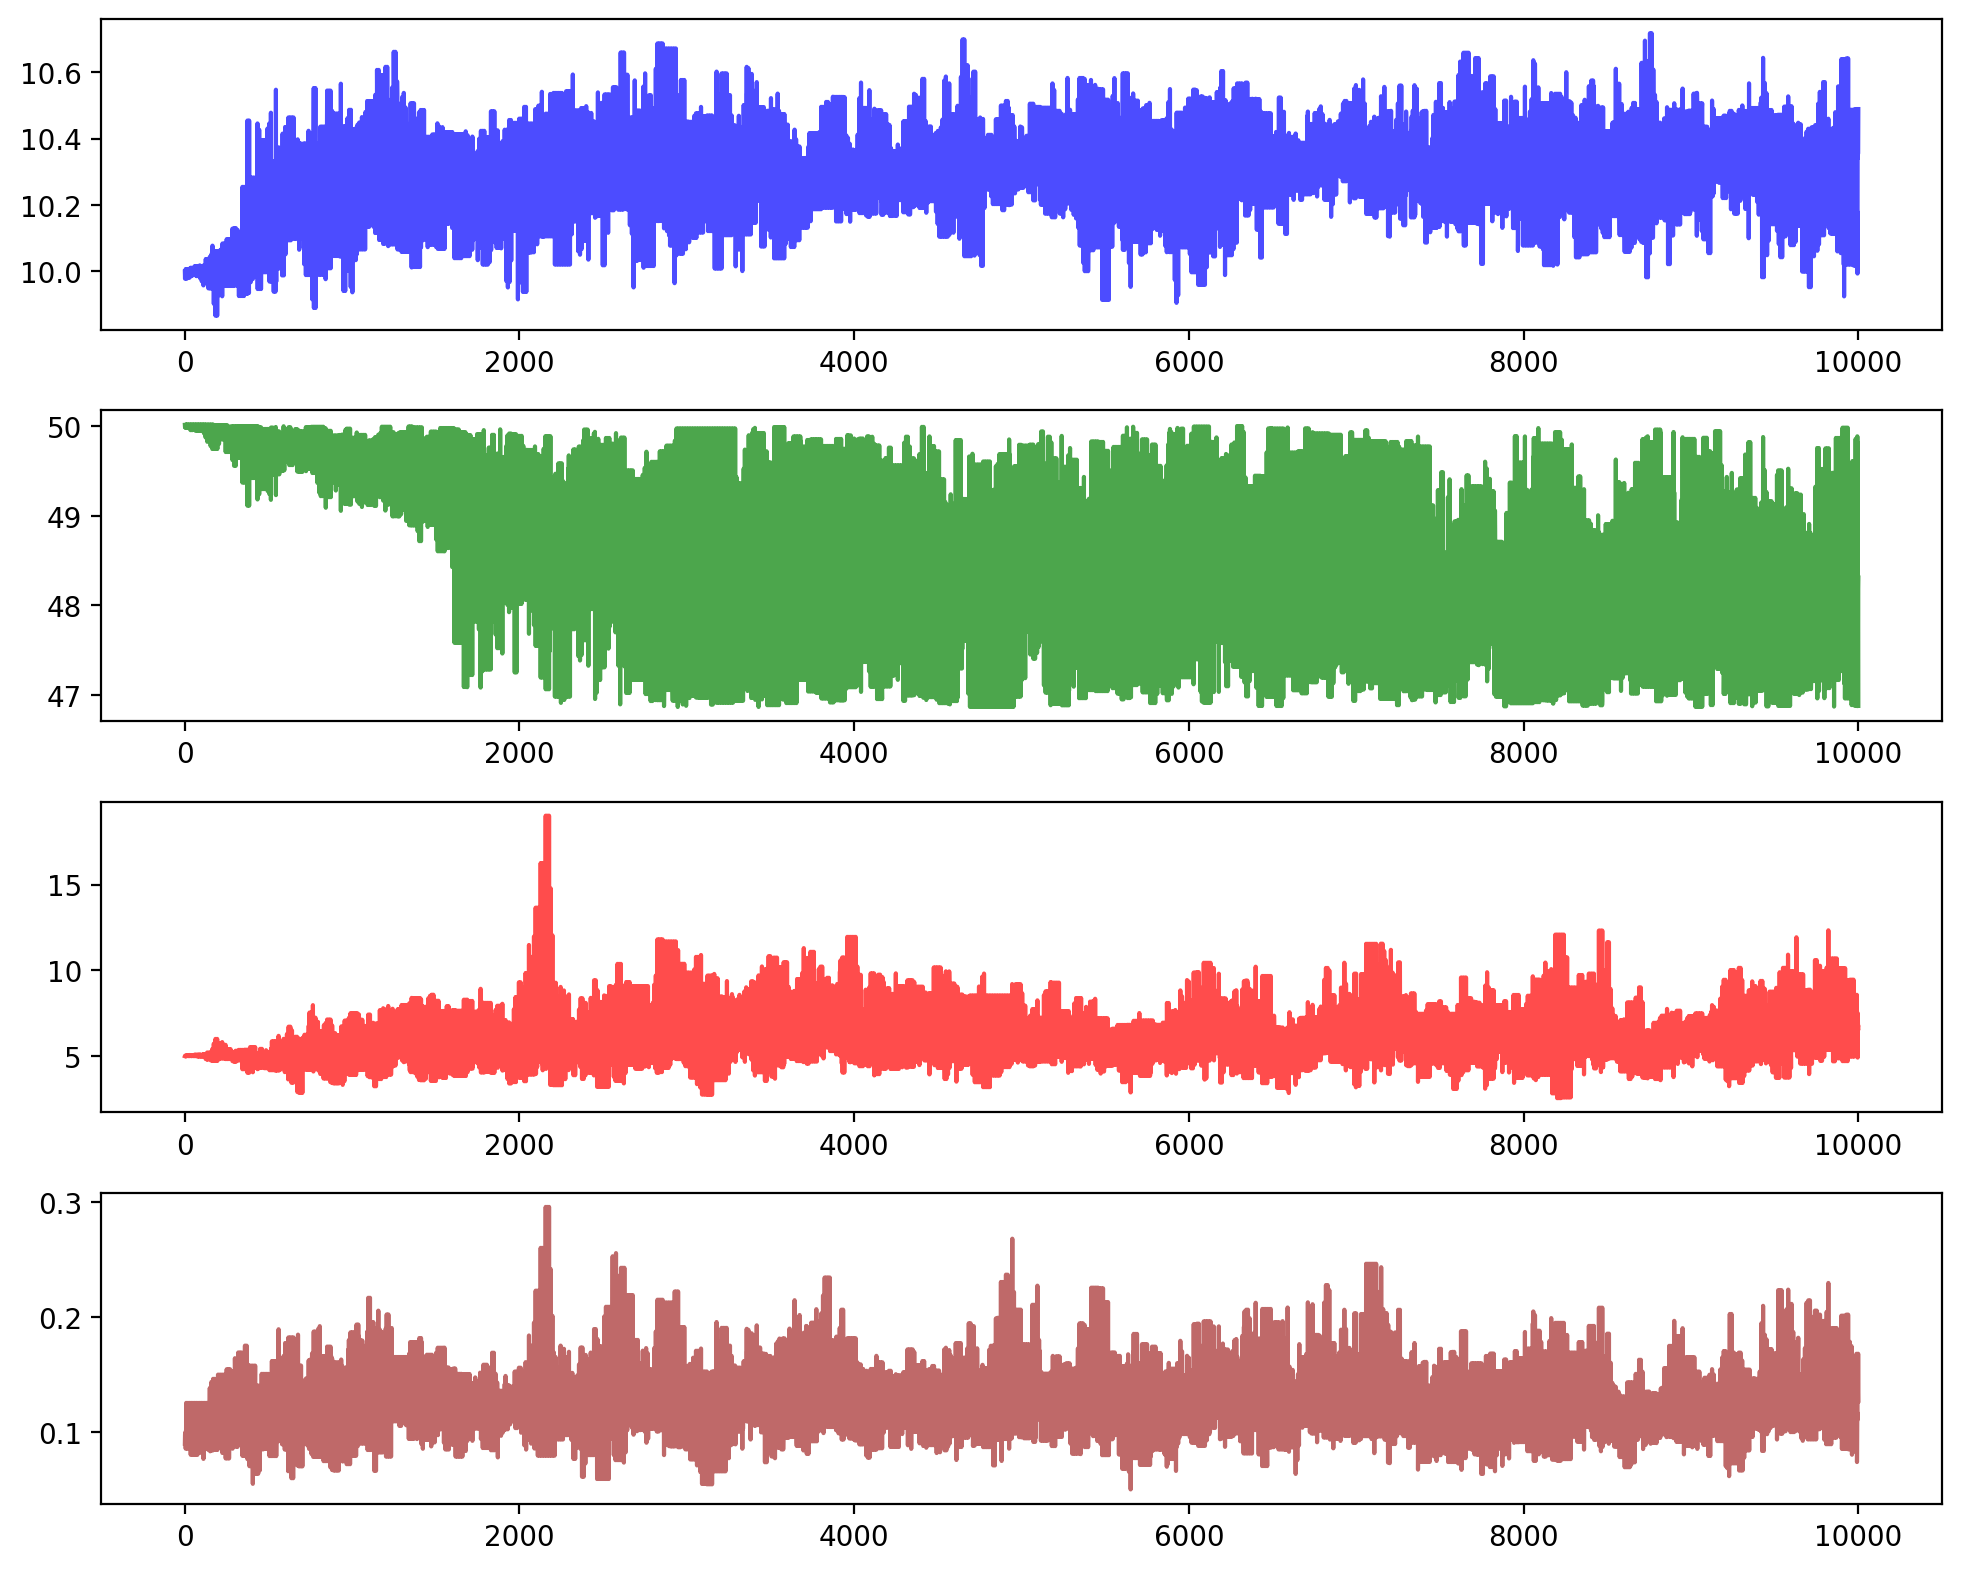

In [7]:

#(flat=True)
#emcee_trace.flatten()
samples = sampler.get_chain(flat = True)

D = np.size(samples[:,2])
xgrid = np.linspace(1, D, D)
#plt.plot(xgrid, samples[:,1])
#plt.show
print(samples.shape)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 8))

axes[0].plot(xgrid, samples[:,0], color='blue', alpha = 0.7)

axes[1].plot(xgrid, samples[:,1], color='green', alpha = 0.7)

axes[2].plot(xgrid, samples[:,2], color='red', alpha = 0.7)

axes[3].plot(xgrid, samples[:,3], color='brown', alpha = 0.7)

plt.tight_layout()

plt.show()

In [8]:
tau = sampler.get_autocorr_time(tol = 0)
print(tau)
autocorr = np.array([],  dtype=int)
for i in range(np.size(tau)):
    autocorr = np.append(autocorr , int(tau[i]+1))

thin = max(autocorr)
#thin = autocorr[1]

[49.97759312 76.95620047 41.31941982 29.90514967]


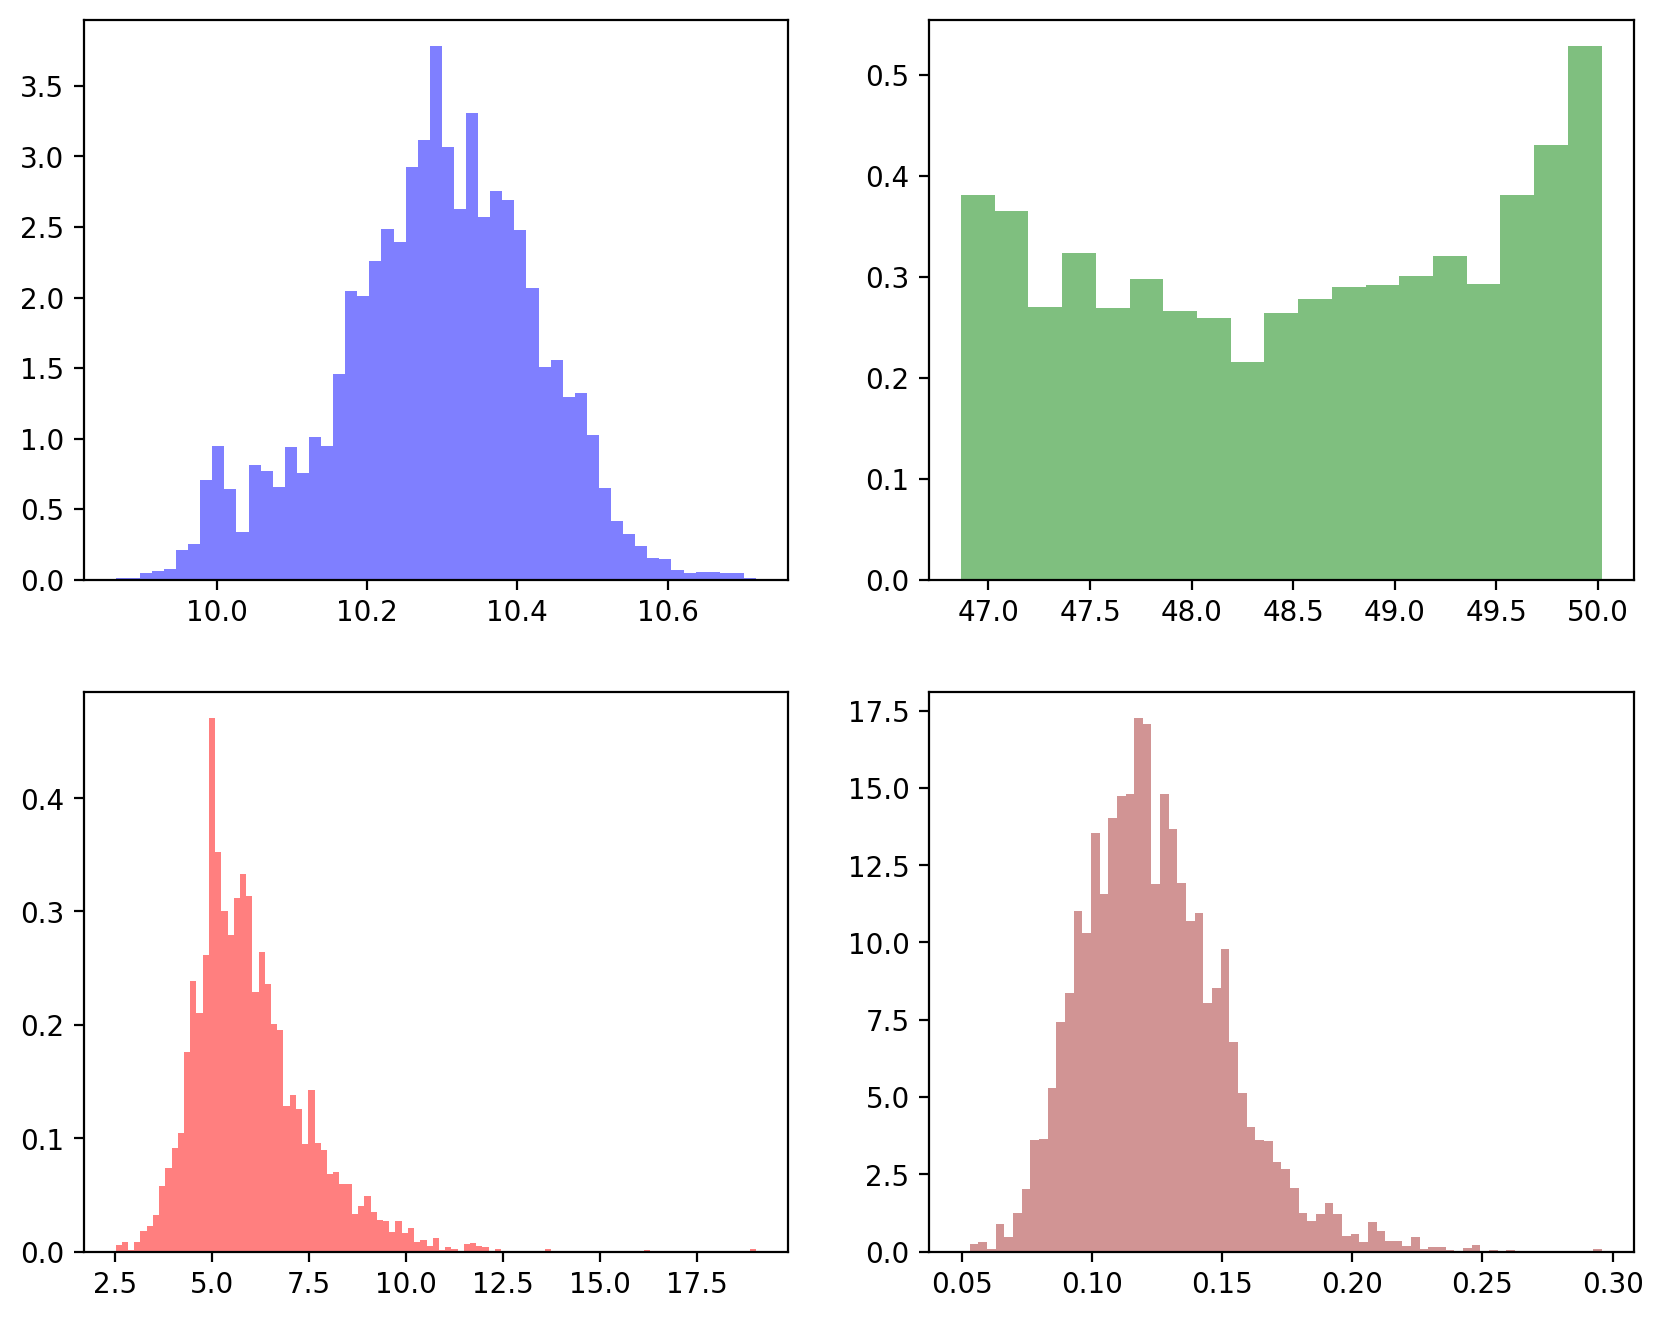

In [9]:
#plt.hist(samples[:,0],bins='auto', histtype='stepfilled',density=True) 
fig2, histo = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

histo[0 , 0].hist(samples[:,0], bins='auto', histtype='stepfilled',density=True, color='blue' , alpha = 0.5)
histo[0,1].hist(samples[:,1], bins='auto', histtype='stepfilled',density=True, color='green' , alpha = 0.5)
histo[1,0].hist(samples[:,2], bins='auto', histtype='stepfilled',density=True, color='red' , alpha = 0.5)
histo[1,1].hist(samples[:,3], bins='auto', histtype='stepfilled',density=True, color='brown' , alpha = 0.5)
plt.show()

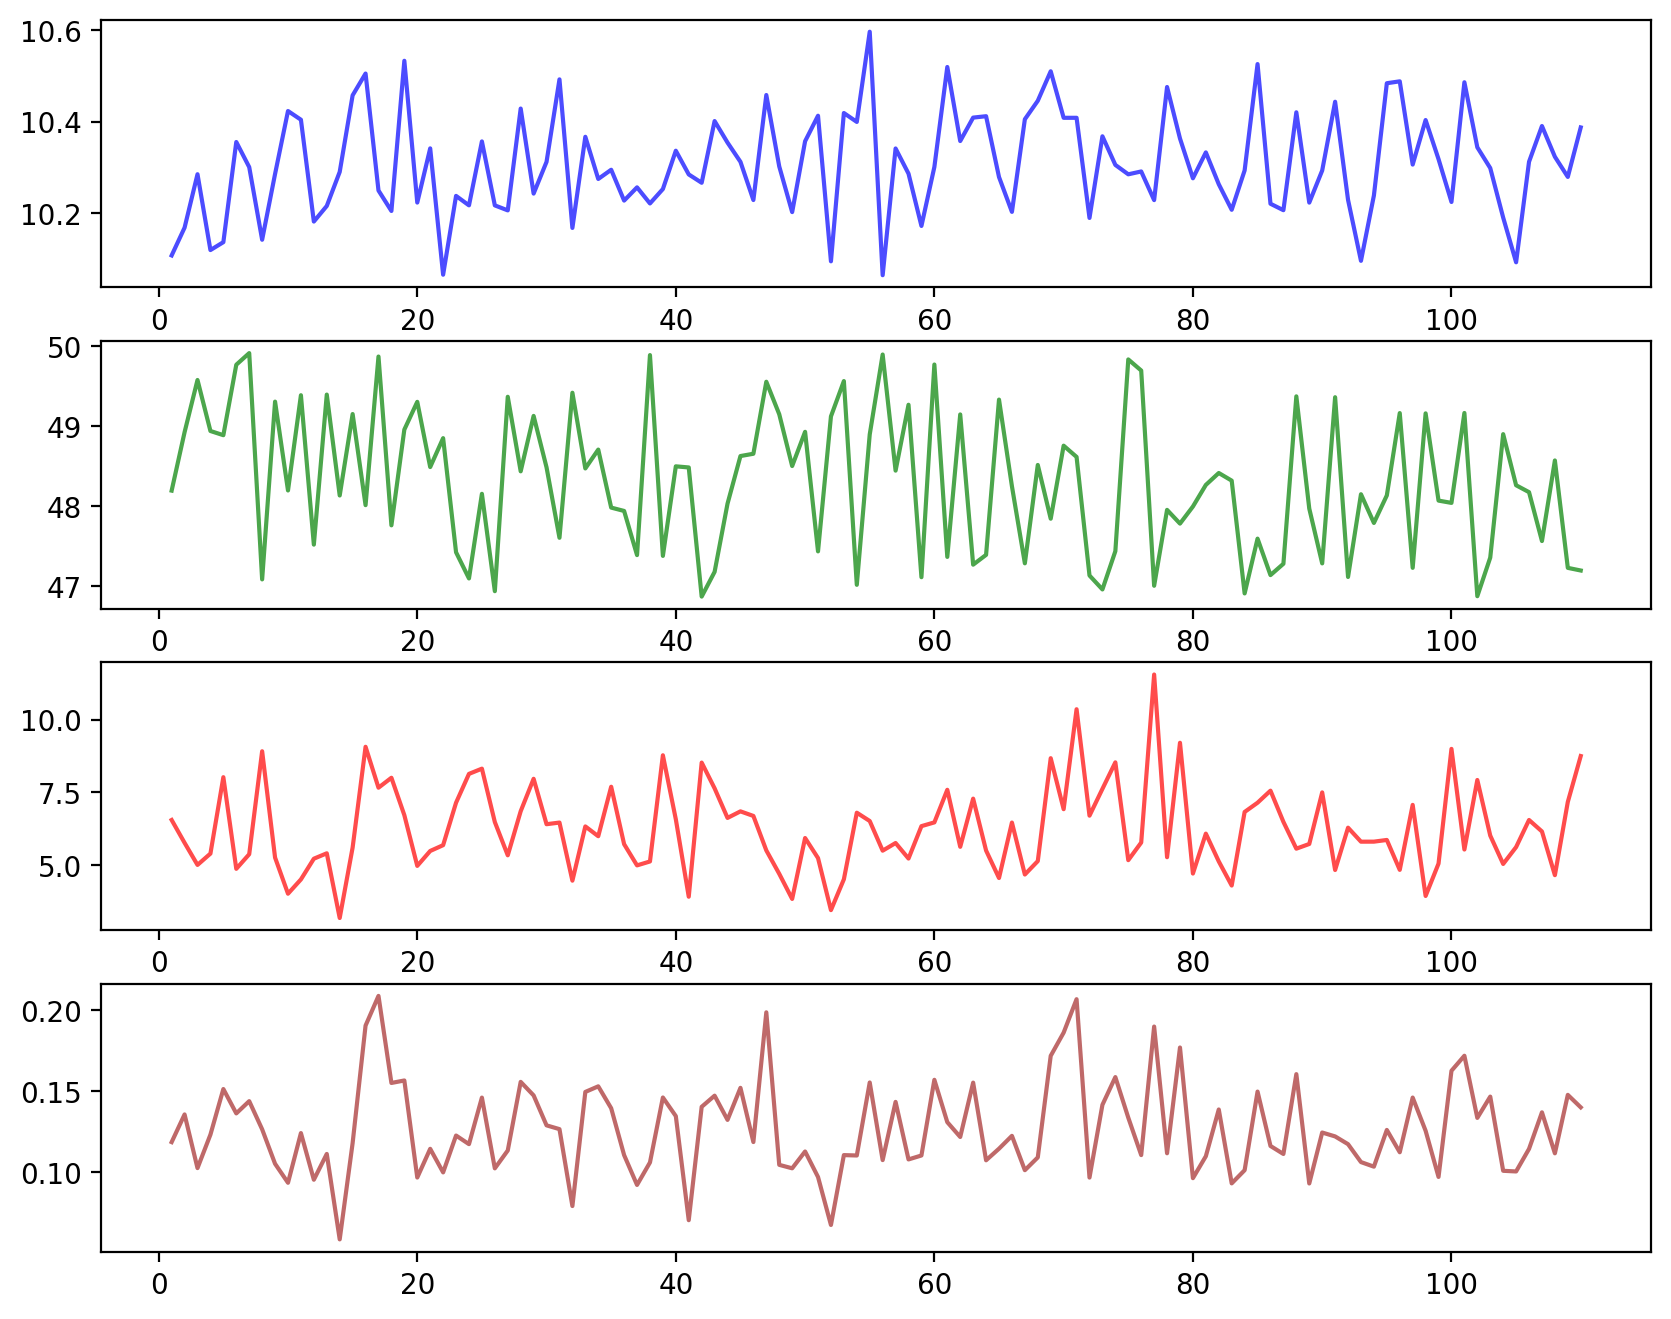

In [10]:
emcee_trace = sampler.get_chain(discard=burn, thin=thin, flat=True)


N = np.size(emcee_trace[:,0])
xgrid = np.linspace(1, N, N)

fig, axes2 = plt.subplots(nrows=4, ncols=1, figsize=(10, 8))

axes2[0].plot(xgrid, emcee_trace[:,0], color='blue', alpha = 0.7)

axes2[1].plot(xgrid, emcee_trace[:,1], color='green', alpha = 0.7)

axes2[2].plot(xgrid, emcee_trace[:,2], color='red', alpha = 0.7)

axes2[3].plot(xgrid, emcee_trace[:,3], color='brown', alpha = 0.7)
#plt.plot(xgrid, emcee_trace[:,2])
plt.show()

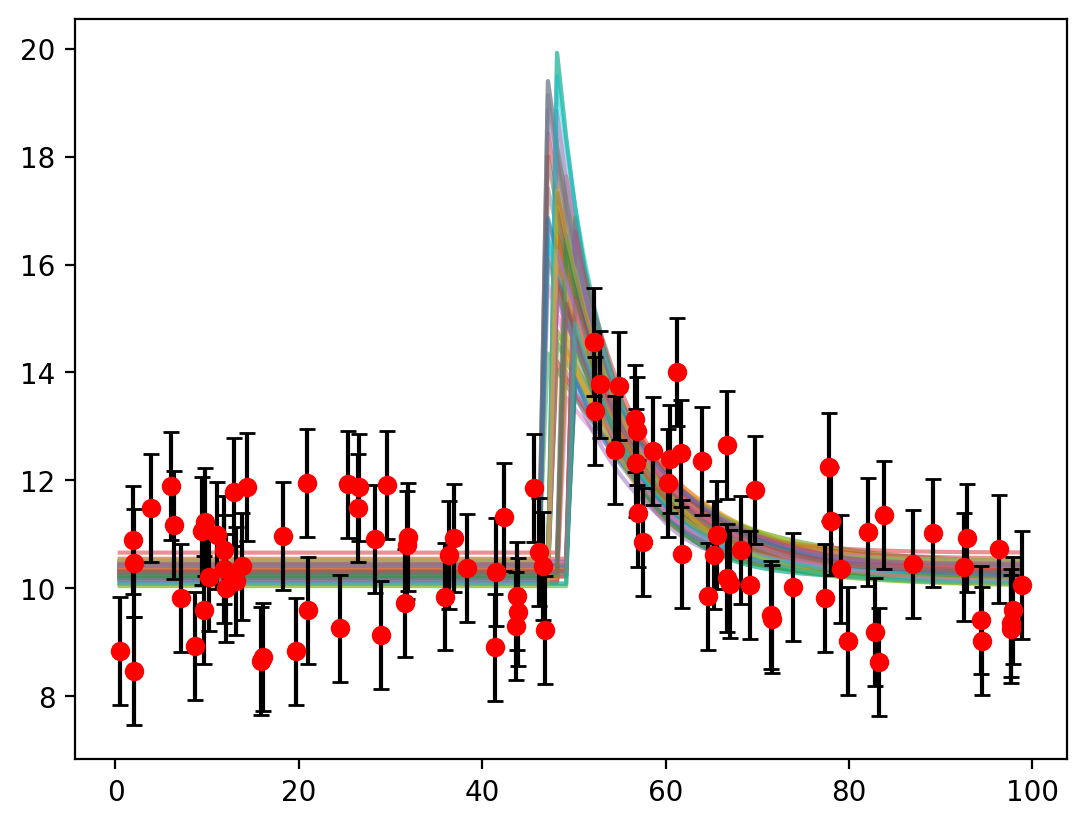

In [11]:
params = np.zeros((100,4))
index = np.random.uniform(burn*10, np.size(samples[:,0]), 100)
x = np.linspace(min(time) , max(time),100)
for i in range (100):
    params[i ,:] = samples[int(index[i]),:]
    plt.plot(x , f(params[i][0], params[i][1] , params[i][2], params[i][3], x),alpha=0.5)
plt.errorbar(data[: , 0], data[: , 1], data[: , 2] ,fmt='ro', ecolor='black', capsize=3)
params
plt.show()

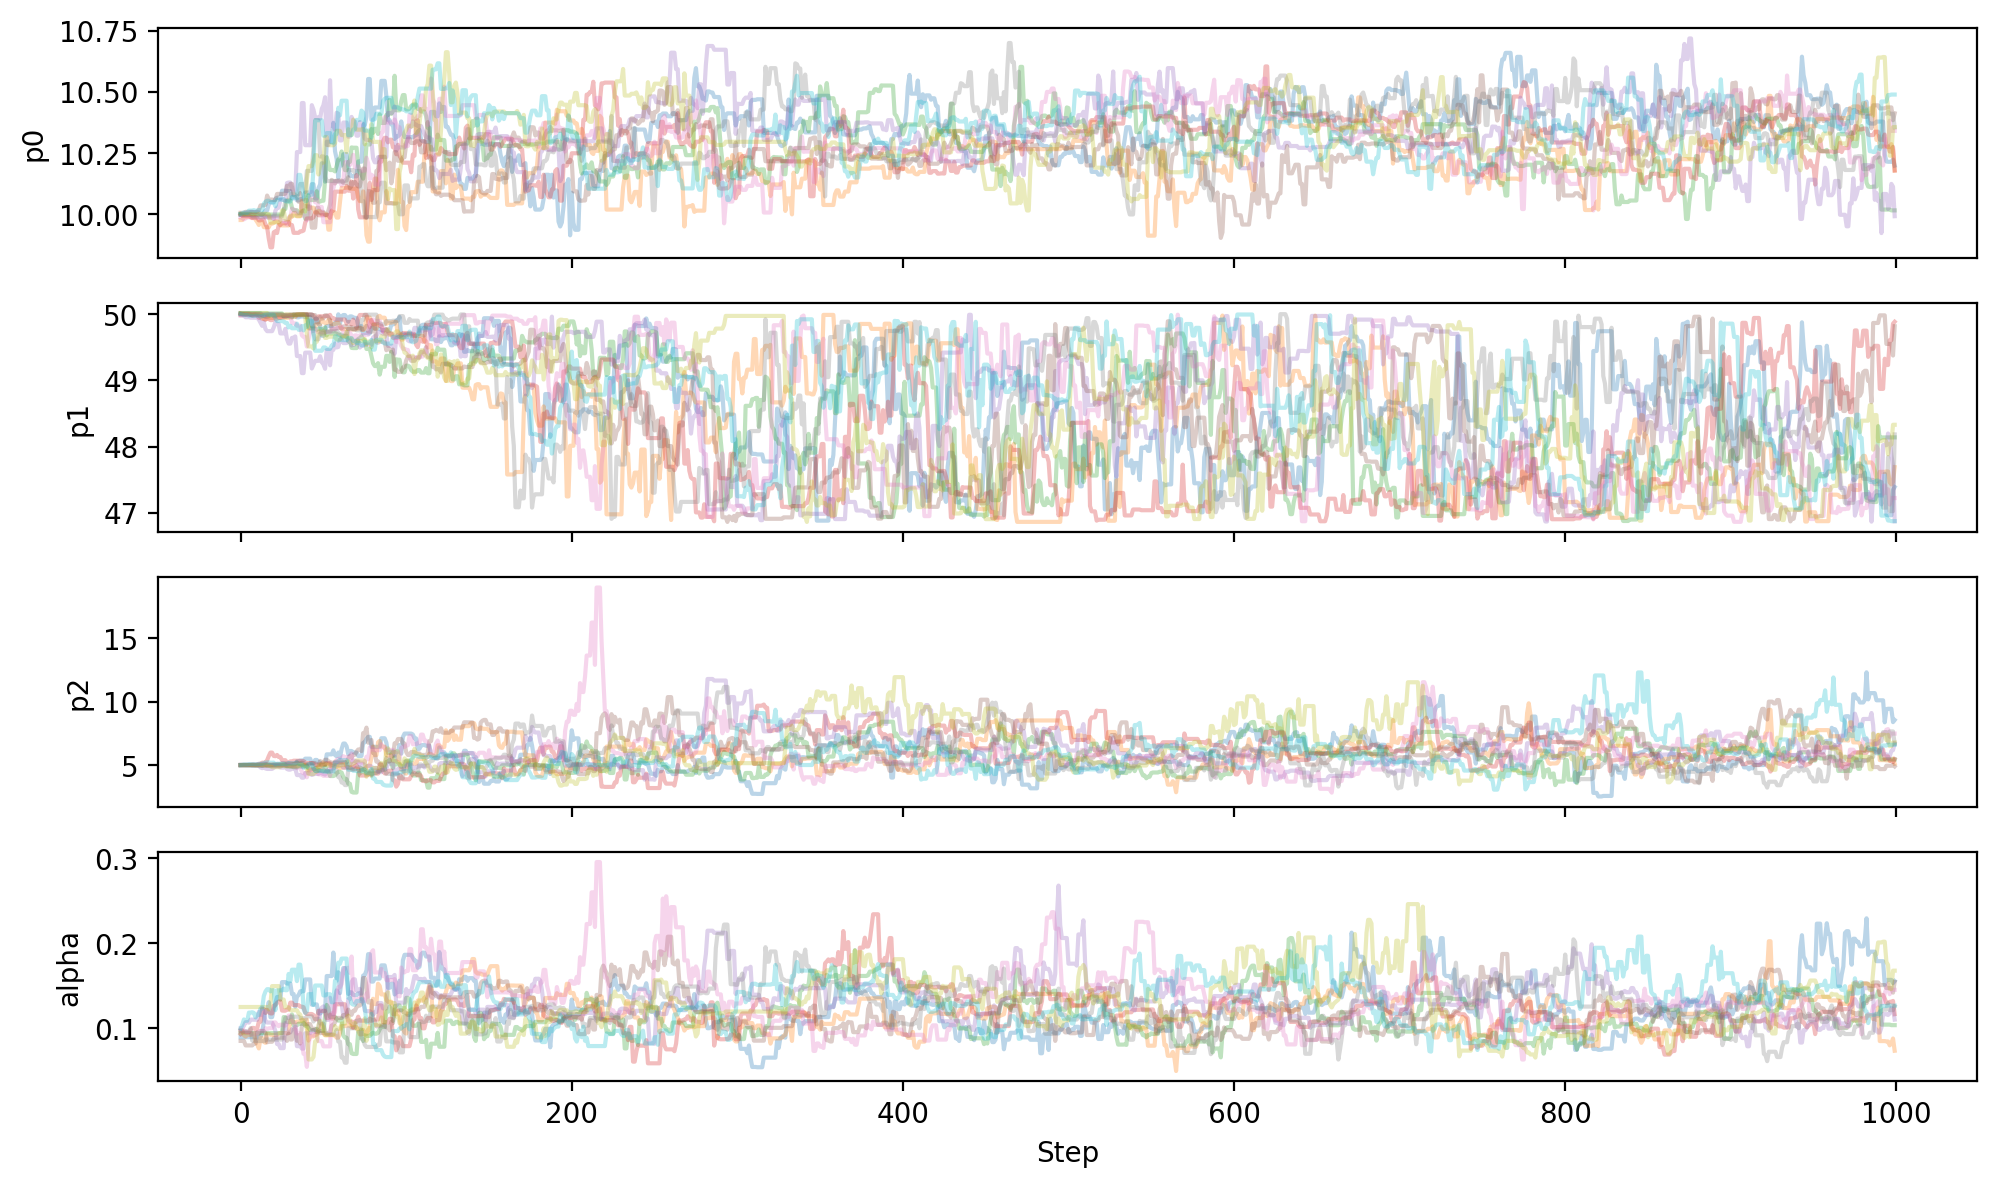

In [12]:
chain = sampler.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 6), sharex=True)
labels = ["p0", "p1", "p2", "alpha"]
for i in range(ndim):
    for walker in range(nwalkers):
        axes[i].plot(chain[:, walker, i], alpha=0.3)
    axes[i].set_ylabel(labels[i])
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

In [13]:
print("Acceptance fraction:", np.mean(sampler.acceptance_fraction))

Acceptance fraction: 0.5358


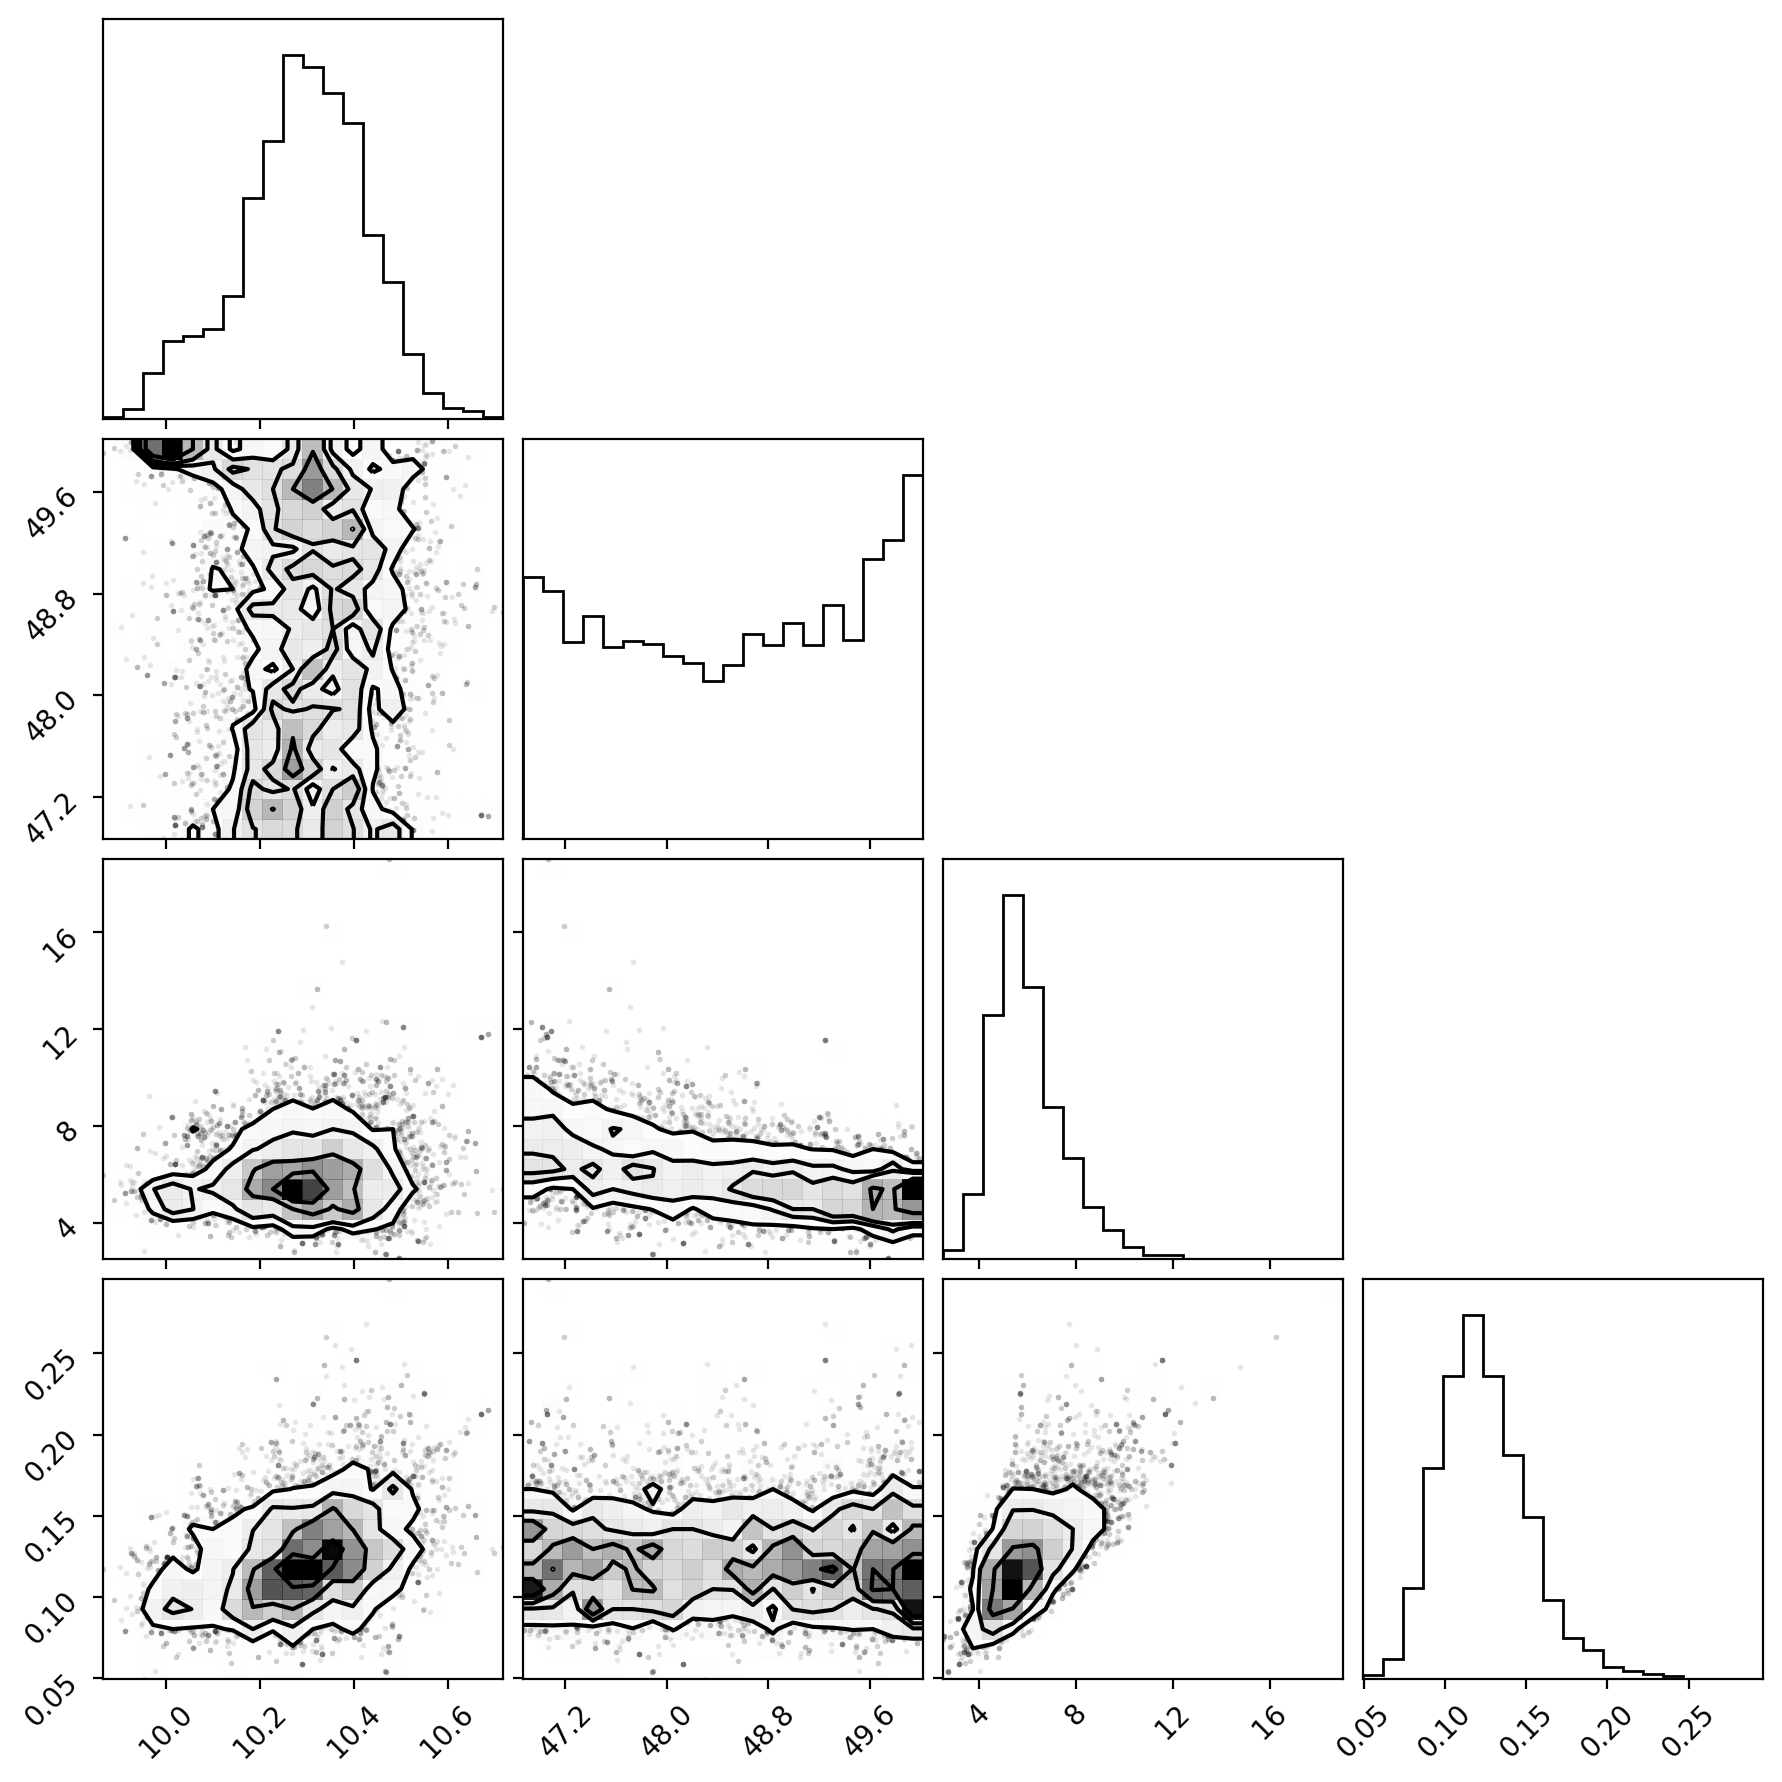

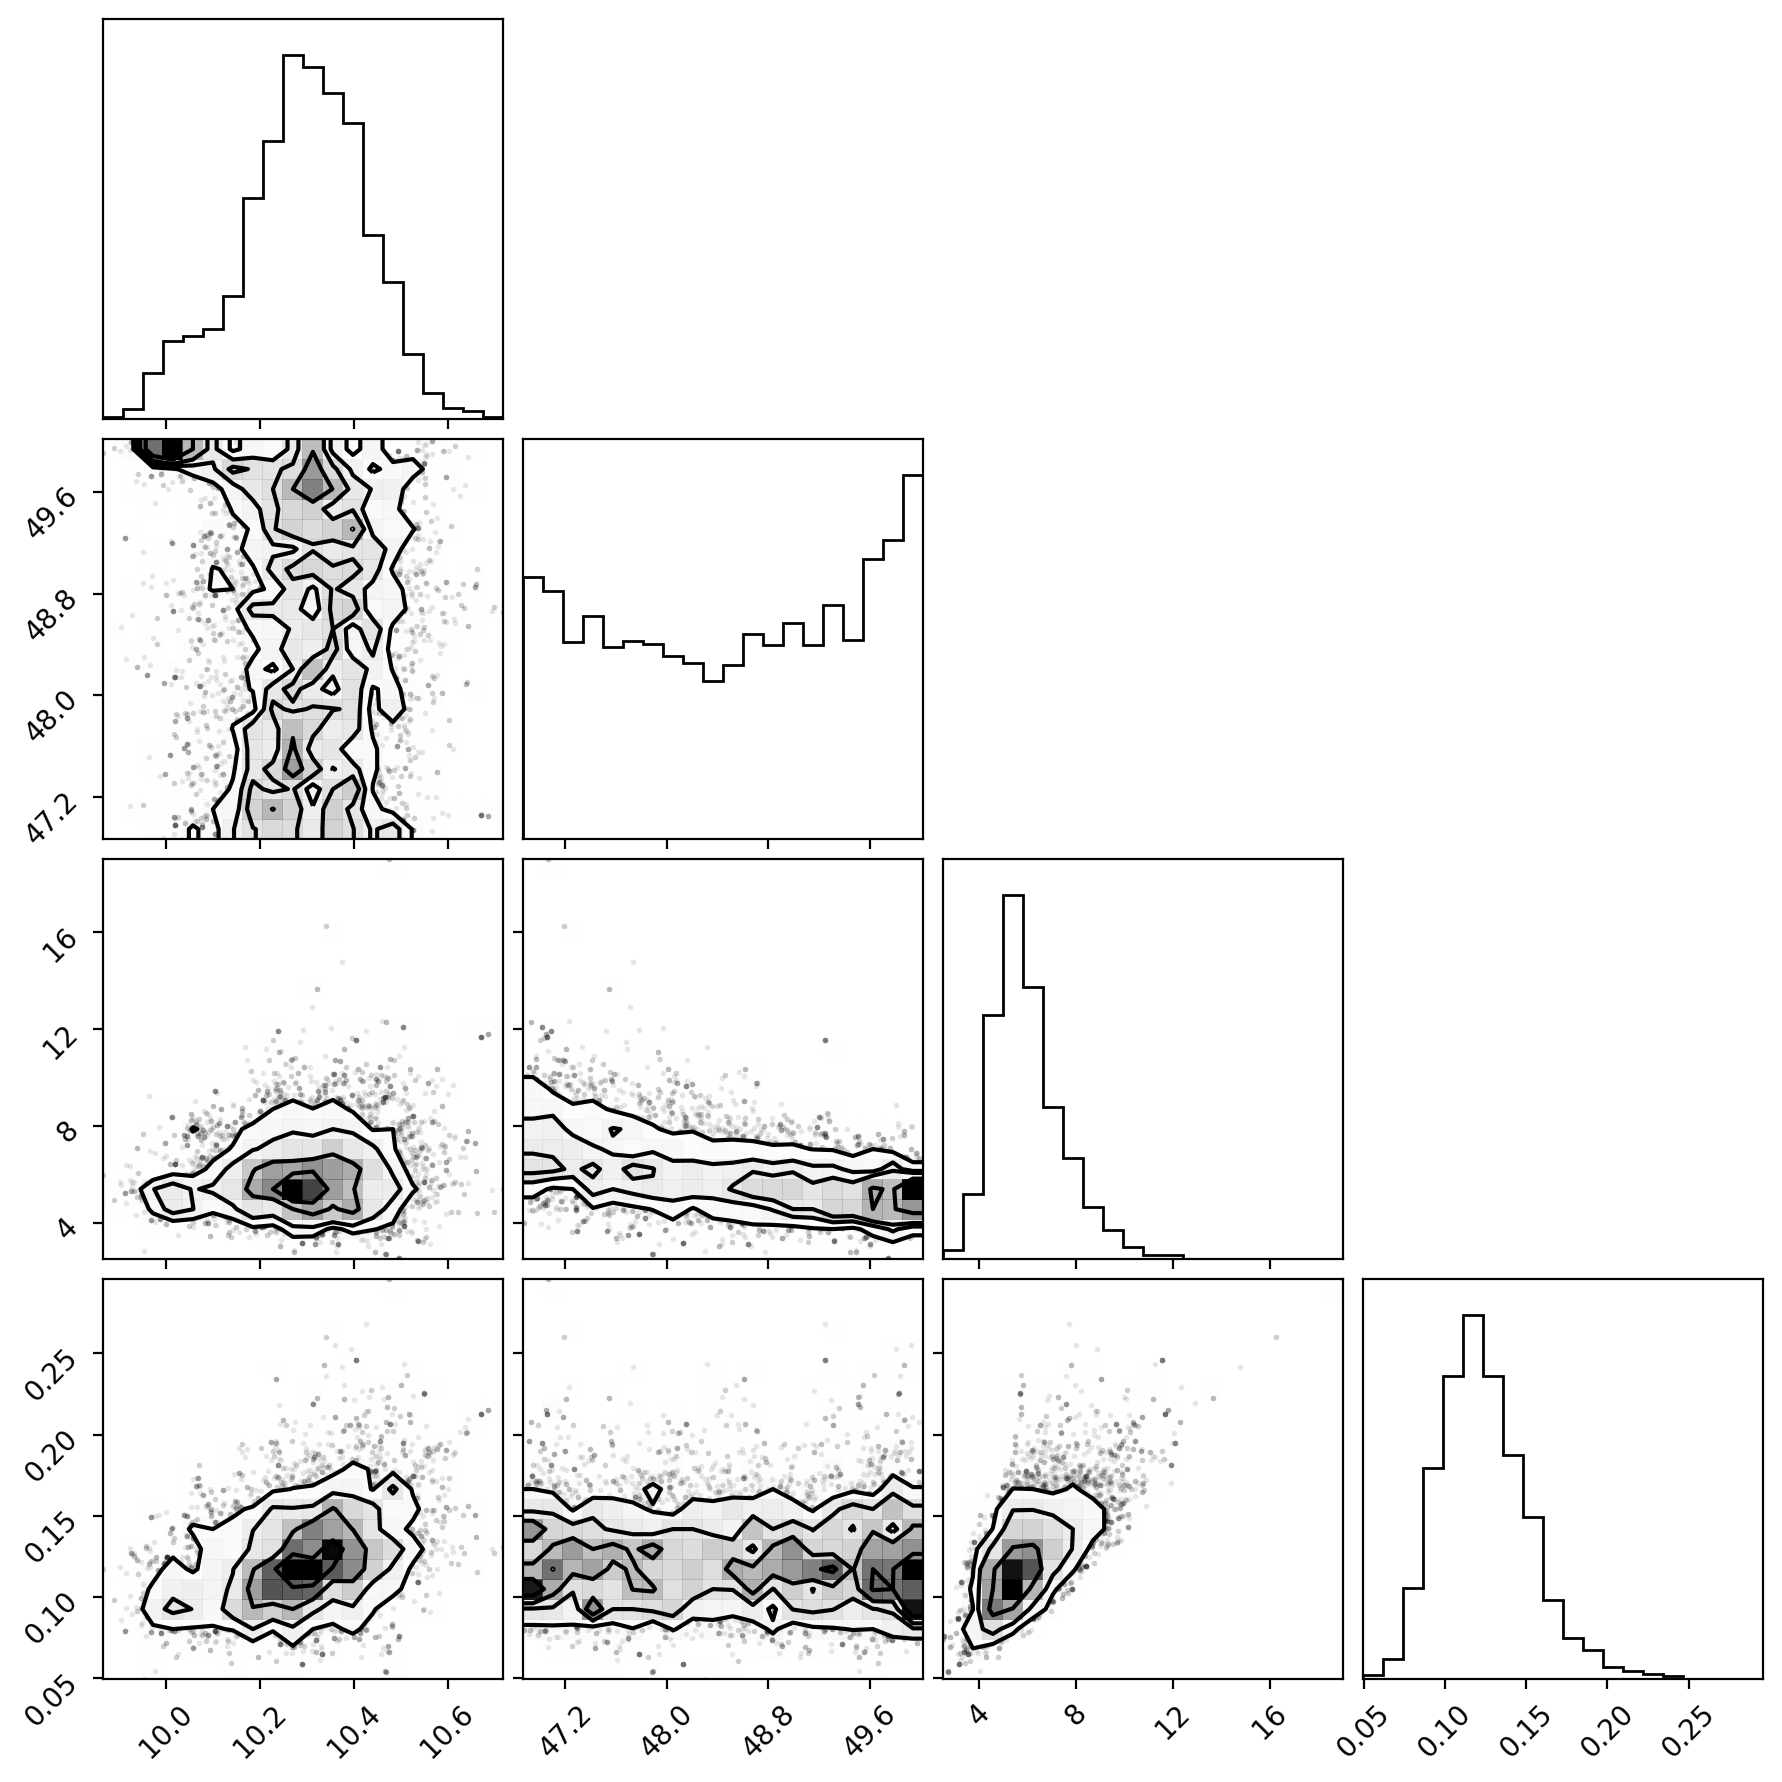

In [14]:
import corner
corner.corner(samples)

<ErrorbarContainer object of 3 artists>

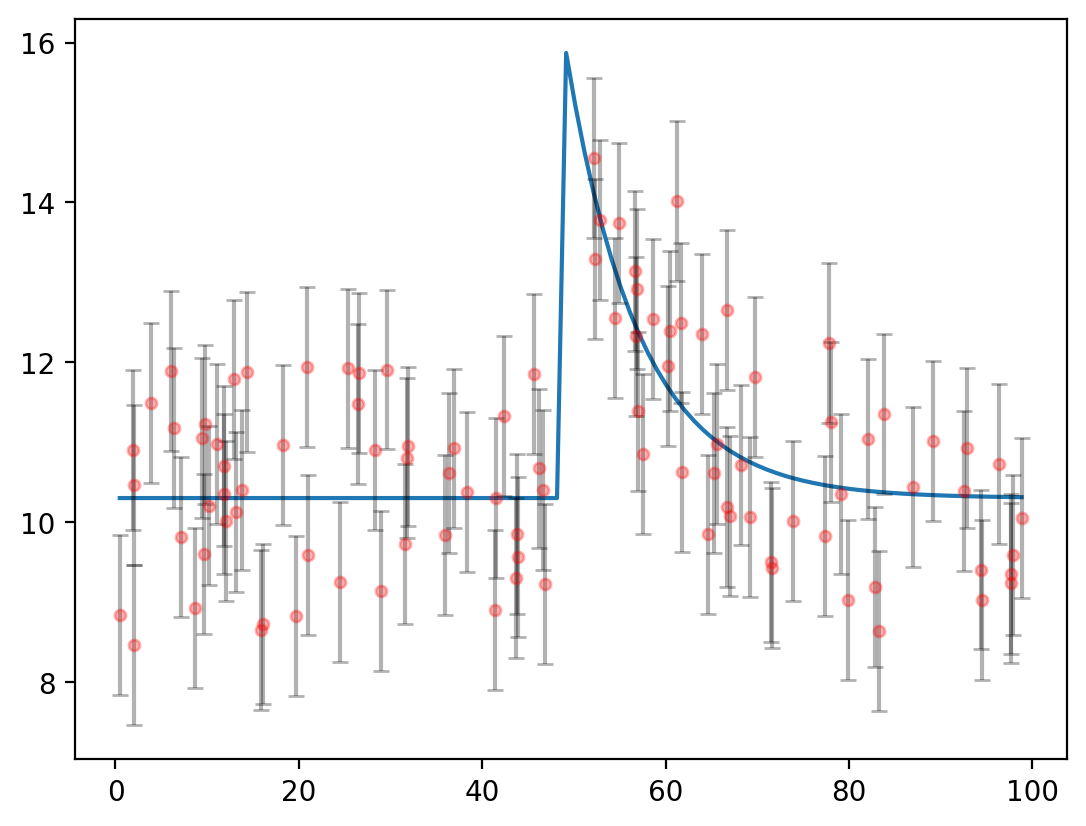

In [15]:
mean_params = np.mean(params, axis = 0) 
plt.plot(x , f(mean_params[0], mean_params[1] , mean_params[2], mean_params[3], x))
plt.errorbar(data[: , 0], data[: , 1], data[: , 2] ,fmt='ro', ecolor='black', capsize=3 , markersize = 4 , alpha = 0.3)